# EDA REHAB24-6

Non era mai stata fatta un'esplorazione vera e propria di questo dataset (a differenza di KIMORE, notebook 01) prima di costruire feature e lanciare modelli. La recupera qui: scheletro (con la mappa dei 26 giunti confermata), conteggi per esercizio/soggetto, distribuzione delle ripetizioni, e le feature anatomiche che nel check univariato hanno mostrato il segnale piu forte visto finora nel progetto.

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)

BASE = Path("../data/ui_prmd/2d_joints_segmented/2d_joints_segmented")
FILENAME_RE = re.compile(r"^(PM_\d+)_c(\d+)_(.+)-rep(\d+)-(\d+)\.npy$")
EXERCISES = ["Ex1", "Ex2", "Ex3", "Ex4", "Ex5", "Ex6"]
EXERCISE_LABELS = {
    "Ex1": "Arm abduction", "Ex2": "Arm VW", "Ex3": "Push-ups",
    "Ex4": "Leg abduction", "Ex5": "Leg lunge", "Ex6": "Squats",
}
JOINT_NAMES = ["Hips","Spine","Spine1","Neck","Head","Head_end","LeftShoulder","LeftArm",
    "LeftForeArm","LeftHand","LeftHand_end","RightShoulder","RightArm","RightForeArm",
    "RightHand","RightHand_end","LeftUpLeg","LeftLeg","LeftFoot","LeftToeBase","LeftToeBase_end",
    "RightUpLeg","RightLeg","RightFoot","RightToeBase","RightToeBase_end"]
print("Mappa dei 26 giunti (da data/ui_prmd/joints_names.txt, dal record Zenodo del dataset):")
for i, n in enumerate(JOINT_NAMES):
    print(f"  {i:2d} {n}")

Mappa dei 26 giunti (da data/ui_prmd/joints_names.txt, dal record Zenodo del dataset):
   0 Hips
   1 Spine
   2 Spine1
   3 Neck
   4 Head
   5 Head_end
   6 LeftShoulder
   7 LeftArm
   8 LeftForeArm
   9 LeftHand
  10 LeftHand_end
  11 RightShoulder
  12 RightArm
  13 RightForeArm
  14 RightHand
  15 RightHand_end
  16 LeftUpLeg
  17 LeftLeg
  18 LeftFoot
  19 LeftToeBase
  20 LeftToeBase_end
  21 RightUpLeg
  22 RightLeg
  23 RightFoot
  24 RightToeBase
  25 RightToeBase_end


## Quanti soggetti, ripetizioni, corrette/scorrette per esercizio

In [2]:
rows = []
frame_counts = []
for ex in EXERCISES:
    ex_dir = BASE / f"{ex}-segmented"
    for f in sorted(ex_dir.iterdir()):
        if f.suffix != ".npy":
            continue
        m = FILENAME_RE.match(f.name)
        if not m:
            continue
        subject, cam, variant, rep, label = m.groups()
        arr = np.load(f)
        rows.append({"exercise": ex, "subject": subject, "rep": int(rep), "correct": int(label),
                      "n_frames": arr.shape[0]})

meta = pd.DataFrame(rows)
summary = meta.groupby("exercise").agg(
    soggetti=("subject", "nunique"), ripetizioni=("rep", "count"),
    corrette=("correct", "sum"), frame_min=("n_frames", "min"),
    frame_medio=("n_frames", "mean"), frame_max=("n_frames", "max"))
summary["scorrette"] = summary["ripetizioni"] - summary["corrette"]
summary["nome"] = [EXERCISE_LABELS[e] for e in summary.index]
print(summary[["nome", "soggetti", "ripetizioni", "corrette", "scorrette",
               "frame_min", "frame_medio", "frame_max"]].to_string(float_format="%.0f"))

                   nome  soggetti  ripetizioni  corrette  scorrette  frame_min  frame_medio  frame_max
exercise                                                                                              
Ex1       Arm abduction         9           88        47         41         83          159        316
Ex2              Arm VW        10          109        48         61         90          173        585
Ex3            Push-ups        10          107        52         55         58          113        241
Ex4       Leg abduction         9          116        63         53         36           89        141
Ex5           Leg lunge         7           76        33         43         49          106        166
Ex6              Squats         9           98        72         26         65          100        155


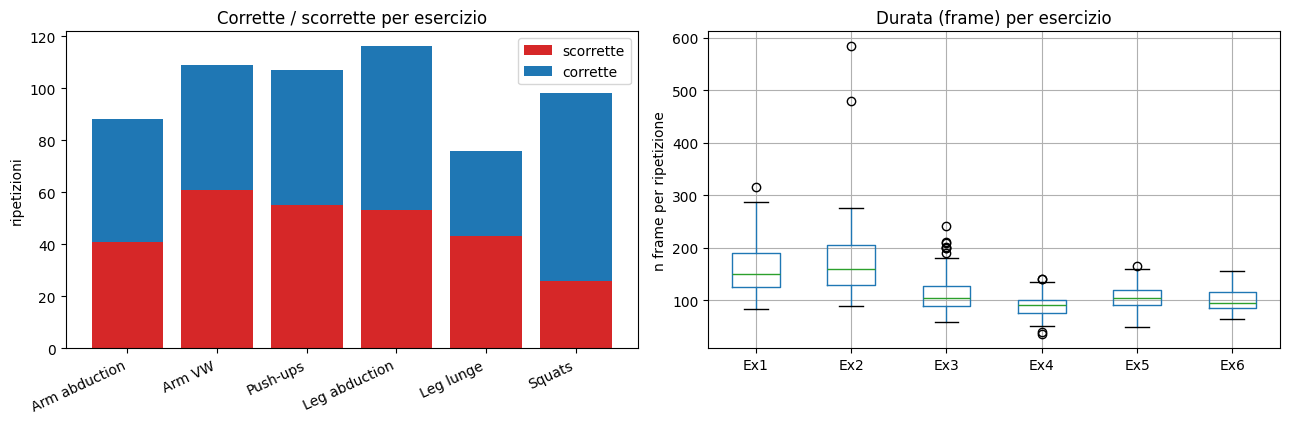

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x = np.arange(len(EXERCISES))
axes[0].bar(x, summary["scorrette"], label="scorrette", color="tab:red")
axes[0].bar(x, summary["corrette"], bottom=summary["scorrette"], label="corrette", color="tab:blue")
axes[0].set_xticks(x)
axes[0].set_xticklabels([EXERCISE_LABELS[e] for e in EXERCISES], rotation=25, ha="right")
axes[0].set_ylabel("ripetizioni")
axes[0].set_title("Corrette / scorrette per esercizio")
axes[0].legend()

meta.boxplot(column="n_frames", by="exercise", ax=axes[1])
axes[1].set_title("Durata (frame) per esercizio")
axes[1].set_xlabel("")
axes[1].set_ylabel("n frame per ripetizione")
plt.suptitle("")
plt.tight_layout()
plt.show()

## Lo scheletro: la mappa dei giunti Ã¨ corretta?

Sanity check visivo (stesso principio usato per KIMORE nel notebook 01): disegna un frame con le connessioni anatomiche attese. Se testa in alto, piedi in basso e braccia/gambe simmetriche, la mappa Ã¨ quella giusta.

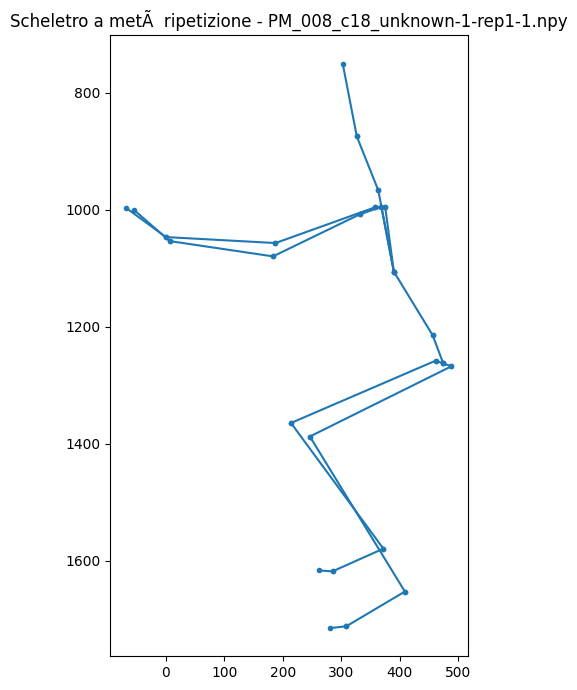

In [4]:
BONES = [
    (0,1),(1,2),(2,3),(3,4),(4,5),               # hips-spine-spine1-neck-head-head_end
    (2,6),(6,7),(7,8),(8,9),(9,10),               # left arm
    (2,11),(11,12),(12,13),(13,14),(14,15),       # right arm
    (0,16),(16,17),(17,18),(18,19),(19,20),       # left leg
    (0,21),(21,22),(22,23),(23,24),(24,25),       # right leg
]

example_file = next((BASE / "Ex6-segmented").glob("*rep1-1.npy"))
arr = np.load(example_file)
frame = arr[len(arr) // 2]  # mid-repetition frame

fig, ax = plt.subplots(figsize=(5, 7))
for a, b in BONES:
    ax.plot([frame[a, 0], frame[b, 0]], [frame[a, 1], frame[b, 1]], "o-", color="tab:blue", markersize=3)
ax.invert_yaxis()  # image-y grows downward
ax.set_aspect("equal")
ax.set_title(f"Scheletro a metÃ  ripetizione - {example_file.name}")
plt.tight_layout()
plt.show()

## Ginocchio nel tempo: una ripetizione corretta vs una scorretta (squat)

Stesso tipo di controllo di plausibilitÃ  fatto per KIMORE: il segnale angolare ha davvero un pattern da squat (discesa-risalita), e le due classi si vedono giÃ  a occhio?

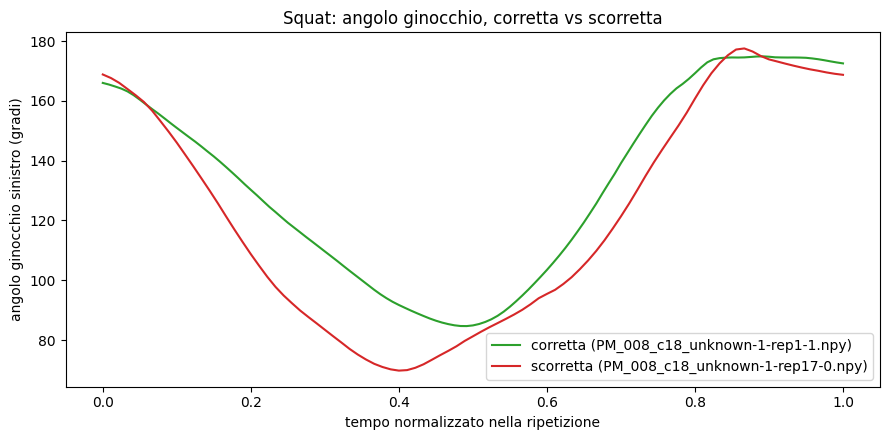

In [5]:
def angle_series(arr, a, b, c):
    pa, pb, pc = arr[:, a], arr[:, b], arr[:, c]
    ba, bc = pa - pb, pc - pb
    cos = np.sum(ba * bc, axis=1) / (np.linalg.norm(ba, axis=1) * np.linalg.norm(bc, axis=1) + 1e-9)
    return np.degrees(np.arccos(np.clip(cos, -1.0, 1.0)))

ex6_dir = BASE / "Ex6-segmented"
correct_file = next(f for f in ex6_dir.glob("*.npy") if f.name.endswith("-1.npy"))
incorrect_file = next(f for f in ex6_dir.glob("*.npy") if f.name.endswith("-0.npy"))

fig, ax = plt.subplots(figsize=(9, 4.5))
for f, label, color in [(correct_file, "corretta", "tab:green"), (incorrect_file, "scorretta", "tab:red")]:
    arr = np.load(f)
    knee = angle_series(arr, 16, 17, 18)  # l_upleg, l_leg, l_foot
    t = np.linspace(0, 1, len(knee))
    ax.plot(t, knee, label=f"{label} ({f.name})", color=color)
ax.set_xlabel("tempo normalizzato nella ripetizione")
ax.set_ylabel("angolo ginocchio sinistro (gradi)")
ax.set_title("Squat: angolo ginocchio, corretta vs scorretta")
ax.legend()
plt.tight_layout()
plt.show()

## Le feature anatomiche: dove si vede davvero la differenza?

Le stesse feature usate nel check univariato (rho fino a 0.66 sulla caviglia in Ex6), qui visualizzate direttamente: distribuzione per classe, non solo un numero di correlazione.

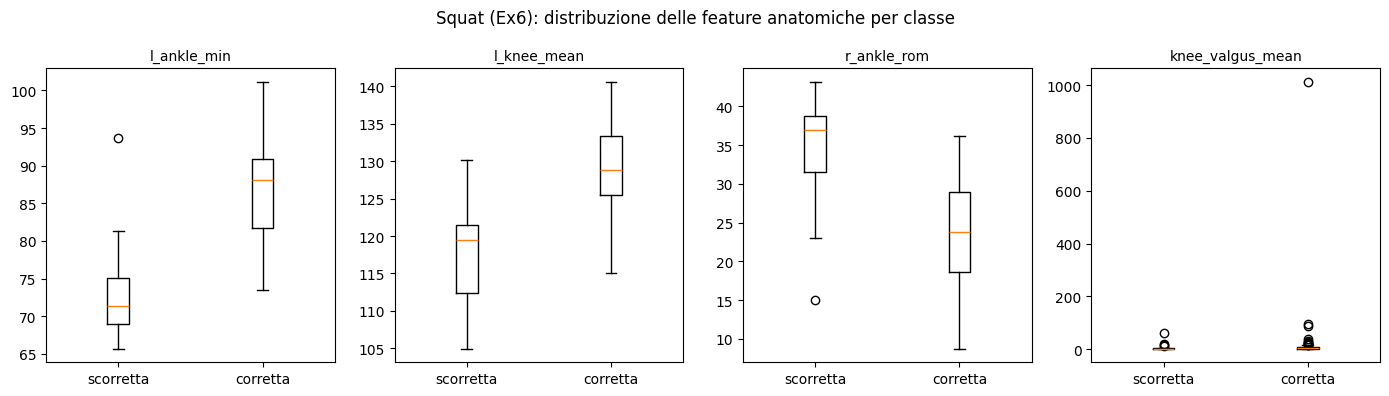

In [6]:
anatomical = pd.read_csv("../data/features_rehab24_ex6_anatomical.csv")
top_features = ["l_ankle_min", "l_knee_mean", "r_ankle_rom", "knee_valgus_mean"]

fig, axes = plt.subplots(1, len(top_features), figsize=(14, 4))
for ax, feat in zip(axes, top_features):
    data = [anatomical[anatomical["correct"] == 0][feat].dropna(),
            anatomical[anatomical["correct"] == 1][feat].dropna()]
    ax.boxplot(data, tick_labels=["scorretta", "corretta"])
    ax.set_title(feat, fontsize=10)
plt.suptitle("Squat (Ex6): distribuzione delle feature anatomiche per classe")
plt.tight_layout()
plt.show()

## Tutte le feature anatomiche insieme: quante per esercizio, quanto sono complete

In [7]:
for ex in ["ex1", "ex2", "ex3", "ex4", "ex5", "ex6"]:
    df = pd.read_csv(f"../data/features_rehab24_{ex}_anatomical.csv")
    n_missing = df.isna().sum().sum()
    print(f"{ex}: {df.shape[0]} righe, {df.shape[1]-2} feature, {n_missing} valori mancanti totali")

ex1: 88 righe, 86 feature, 176 valori mancanti totali
ex2: 109 righe, 86 feature, 216 valori mancanti totali
ex3: 107 righe, 86 feature, 214 valori mancanti totali
ex4: 116 righe, 86 feature, 218 valori mancanti totali
ex5: 76 righe, 86 feature, 150 valori mancanti totali
ex6: 98 righe, 86 feature, 194 valori mancanti totali


## Conclusioni operative

- La mappa dei 26 giunti Ã¨ confermata visivamente (scheletro coerente, testa/piedi/lati corretti).
- Il pattern squat (discesa-risalita del ginocchio) Ã¨ visibile e le due classi mostrano gia' a occhio una differenza nella profondita'/angolo.
- Le feature anatomiche (caviglia, ginocchio, valgismo) separano le classi in modo netto, non solo statisticamente ma visivamente - coerente con l'intuizione clinica reale.
- Prossimo passo: la nested CV per soggetto (in `results/experiments.csv`) dice se questo segnale generalizza a soggetti mai visti, non solo se le distribuzioni si separano.